# Bayes Classifier
## Example

Consider the following small dataset for predicting whether a customer will purchase a product based on two features: *Age* (young, middle, old) and *Income* (low, medium, high).

| ID | Age    | Income  | Purchase? |
|----|--------|---------|----------|
| 1  | Young  | Low     | No       |
| 2  | Young  | Medium  | No       |
| 3  | Young  | High    | Yes      |
| 4  | Middle | Low     | Yes      |
| 5  | Middle | Medium  | Yes      |
| 6  | Middle | High    | Yes      |
| 7  | Old    | Low     | No       |
| 8  | Old    | Medium  | No       |
| 9  | Old    | High    | Yes      |
| 10 | Old    | High    | Yes      |

*Training data for purchase prediction*

We want to classify a new customer with *Age = Young* and *Income = Medium*.

In [2]:
import pandas as pd
import math

data = {
    'ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Age': ['Young', 'Young', 'Young', 'Middle', 'Middle', 'Middle', 'Old', 'Old', 'Old', 'Old'],
    'Income': ['Low', 'Medium', 'High', 'Low', 'Medium', 'High', 'Low', 'Medium', 'High', 'High'],
    'Purchase': ['No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes']
}
df = pd.DataFrame(data)

new_customer = {'Age': 'Young', 'Income': 'Medium'}

def naive_bayes_predict(df, target_col, features, new_instance):
    """
    Predict the class for a new instance using Naïve Bayes.
    Assumes all features are categorical.
    """
    classes = df[target_col].unique()
    
    priors = {}
    for c in classes:
        priors[c] = len(df[df[target_col] == c]) / len(df)
    
    # For each class, compute log probability (to avoid underflow)
    log_probs = {}
    for c in classes:
        # Start with log of prior
        log_prob = math.log(priors[c])
        
        # For each feature, compute conditional probability and add its log
        for feature, value in new_instance.items():
            # Count instances of this class with this feature value
            class_subset = df[df[target_col] == c]
            count_feature = len(class_subset[class_subset[feature] == value])
            # Laplace smoothing (add 1 to numerator, add number of distinct values to denominator)
            distinct_values = df[feature].nunique()
            conditional_prob = (count_feature + 1) / (len(class_subset) + distinct_values)
            log_prob += math.log(conditional_prob)
        
        log_probs[c] = log_prob
    
    
    # get class label
    predicted_class = max(log_probs, key=log_probs.get)
    
    exp_probs = {c: math.exp(log_probs[c]) for c in classes}
    total = sum(exp_probs.values())
    prob_yes = exp_probs.get('Yes', 0) / total if total > 0 else 0
    prob_no = exp_probs.get('No', 0) / total if total > 0 else 0
    
    return predicted_class, prob_yes, prob_no

# 4. Run prediction
predicted, prob_yes, prob_no = naive_bayes_predict(
    df, 
    target_col='Purchase',
    features=['Age', 'Income'],
    new_instance=new_customer
)

print(f"New customer: Age={new_customer['Age']}, Income={new_customer['Income']}")
print(f"Predicted purchase: {predicted}")
print(f"Probability of Yes: {prob_yes:.4f}")
print(f"Probability of No:  {prob_no:.4f}")

New customer: Age=Young, Income=Medium
Predicted purchase: No
Probability of Yes: 0.2874
Probability of No:  0.7126


## Using Scikit-Learn
### Use Categorical NB
#### For Categorial Features

In [3]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB

data = {
    'Age': ['Young', 'Young', 'Young', 'Middle', 'Middle', 'Middle', 'Old', 'Old', 'Old', 'Old'],
    'Income': ['Low', 'Medium', 'High', 'Low', 'Medium', 'High', 'Low', 'Medium', 'High', 'High'],
    'Purchase': ['No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes']
}
df = pd.DataFrame(data)

# 2. Encode Categorical Features
# OrdinalEncoder converts 'Young', 'Middle', 'Old' into 0, 1, 2
feature_encoder = OrdinalEncoder()
X = feature_encoder.fit_transform(df[['Age', 'Income']])

# LabelEncoder converts 'No', 'Yes' into 0, 1
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df['Purchase'])

# CategoricalNB automatically applies Laplace smoothing (alpha=1.0)
model = CategoricalNB(alpha=1.0)
model.fit(X, y)

new_customer = pd.DataFrame([['Young', 'Medium']], columns=['Age', 'Income'])
new_customer_encoded = feature_encoder.transform(new_customer)

predicted_encoded = model.predict(new_customer_encoded)
probabilities = model.predict_proba(new_customer_encoded)

predicted_label = target_encoder.inverse_transform(predicted_encoded)[0]
prob_no, prob_yes = probabilities[0]

print(f"New customer: Age=Young, Income=Medium")
print(f"Predicted purchase: {predicted_label}")
print(f"Probability of No:  {prob_no:.4f}")
print(f"Probability of Yes: {prob_yes:.4f}")

New customer: Age=Young, Income=Medium
Predicted purchase: No
Probability of No:  0.7126
Probability of Yes: 0.2874


## Gaussian Naive Bayes Classifier
### For Continous Features

In [4]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB

data = {
    'Temp_Celsius': [35.2, 40.5, 85.1, 79.3, 38.0, 92.4, 42.1, 88.5],
    'CPU_Load_Pct': [10.5, 22.1, 95.4, 88.2, 15.0, 99.1, 20.4, 91.0],
    'Fail': ['No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes']
}
df = pd.DataFrame(data)

# Features (X) and Target (y)
X = df[['Temp_Celsius', 'CPU_Load_Pct']]
y = df['Fail']

model = GaussianNB()
model.fit(X, y)

new_data = pd.DataFrame([[80.0, 90.0]], columns=['Temp_Celsius', 'CPU_Load_Pct'])

prediction = model.predict(new_data)
probs = model.predict_proba(new_data)

print(f"New Data:\n{new_data}\n")
print(f"Prediction: {prediction[0]}")
print(f"Probability of No Fail: {probs[0][0]:.4f}")
print(f"Probability of Fail:    {probs[0][1]:.4f}")

New Data:
   Temp_Celsius  CPU_Load_Pct
0          80.0          90.0

Prediction: Yes
Probability of No Fail: 0.0000
Probability of Fail:    1.0000


# Decision Tree Classifier
### 3.1 Decision Tree Construction: The "Play Tennis" Example

We will build a decision tree using **Information Gain** based on Quinlan's classic weather dataset.

| Outlook | Temperature | Humidity | Windy | Play? |
| :--- | :--- | :--- | :--- | :--- |
| Sunny | Hot | High | False | No |
| Sunny | Hot | High | True | No |
| Overcast | Hot | High | False | Yes |
| Rainy | Mild | High | False | Yes |
| Rainy | Cool | Normal | False | Yes |
| Rainy | Cool | Normal | True | No |
| Overcast | Cool | Normal | True | Yes |
| Sunny | Mild | High | False | No |
| Sunny | Cool | Normal | False | Yes |
| Rainy | Mild | Normal | False | Yes |
| Sunny | Mild | Normal | True | Yes |
| Overcast | Mild | High | True | Yes |
| Overcast | Hot | Normal | False | Yes |
| Rainy | Mild | High | True | No |

---

#### Step 1: Compute the Entropy of the Target Variable
Before we split the data, we must calculate the total uncertainty (Entropy) of the "Play?" column.

* **Total instances ($n$):** 14
* **Yes ($p_{+}$):** 9
* **No ($p_{-}$):** 5

The formula for Entropy $H(S)$ is:
$$H(S) = -p_{+} \log_{2}(p_{+}) - p_{-} \log_{2}(p_{-})$$

Substituting our values:
$$H(S) = -\left(\frac{9}{14}\right) \log_{2}\left(\frac{9}{14}\right) - \left(\frac{5}{14}\right) \log_{2}\left(\frac{5}{14}\right)$$
$$H(S) \approx 0.940$$

#### Step 2: Next Steps
To find the **Root Node**, we will calculate the **Information Gain** for each feature (*Outlook, Temperature, Humidity, Windy*) and choose the one that reduces entropy the most.

In [5]:
import pandas as pd
import numpy as np

# 1. Create the Dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 'Rainy', 'Overcast', 
                'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Overcast', 'Overcast', 'Rainy'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 
                    'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Windy': [False, True, False, False, False, True, True, False, False, False, True, True, False, True],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

def calculate_entropy(target_col):
    """Calculates the entropy of a series."""
    proportions = target_col.value_counts(normalize=True)
    return -sum(p * np.log2(p) for p in proportions)

def calculate_info_gain(df, feature, target):
    """Calculates the Information Gain of a feature relative to the target."""
    # Total entropy before split
    total_entropy = calculate_entropy(df[target])
    
    # Calculate weighted entropy after split
    values = df[feature].unique()
    weighted_entropy = 0
    
    for val in values:
        subset = df[df[feature] == val]
        prob = len(subset) / len(df)
        weighted_entropy += prob * calculate_entropy(subset[target])
        
    return total_entropy - weighted_entropy

# 3. Execution
root_entropy = calculate_entropy(df['Play'])
print(f"Total Entropy of System: {root_entropy:.4f}\n")

features = ['Outlook', 'Temperature', 'Humidity', 'Windy']
gains = {feat: calculate_info_gain(df, feat, 'Play') for feat in features}

print("Information Gain for each feature:")
for feat, gain in gains.items():
    print(f"- {feat}: {gain:.4f}")

best_feature = max(gains, key=gains.get)
print(f"\nBest feature to split on (Root Node): {best_feature}")

Total Entropy of System: 0.9403

Information Gain for each feature:
- Outlook: 0.2467
- Temperature: 0.0292
- Humidity: 0.1518
- Windy: 0.0481

Best feature to split on (Root Node): Outlook


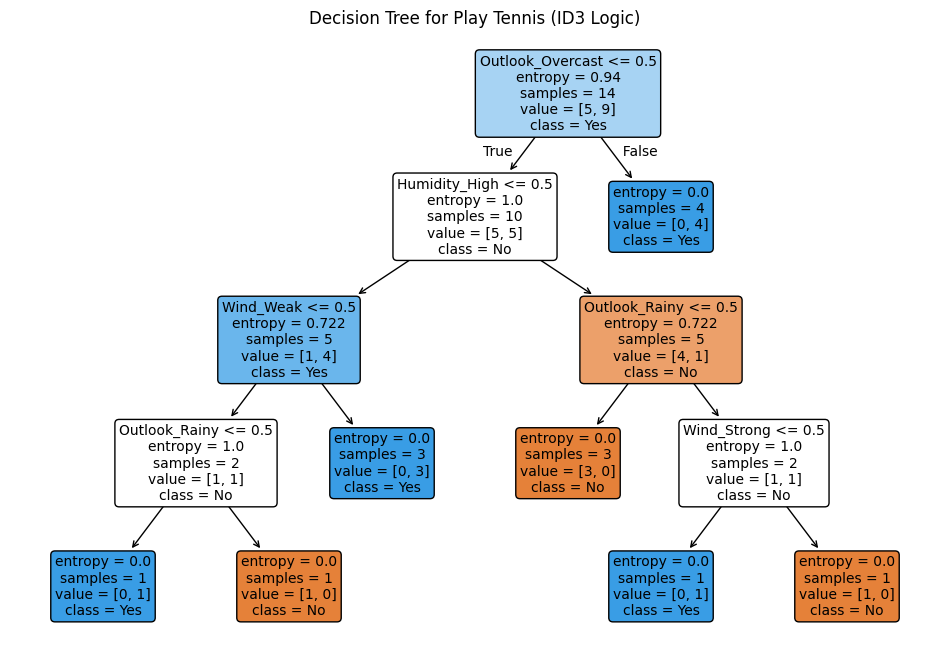

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 'Rainy', 'Overcast', 
                'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Overcast', 'Overcast', 'Rainy'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 
             'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 
             'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)

# We drop the first category to avoid multicollinearity (Standard Practice)
X = pd.get_dummies(df.drop('Play', axis=1))
y = df['Play']

# We use criterion='entropy' to match your manual calculation
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, y)

plt.figure(figsize=(12, 8))
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['No', 'Yes'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree for Play Tennis (ID3 Logic)")
plt.show()

## Prediction

In [7]:
import pandas as pd

# Let's say: Outlook=Sunny, Temp=Mild, Humidity=Normal, Wind=Weak
new_day = {
    'Outlook': 'Sunny',
    'Temp': 'Mild',
    'Humidity': 'Normal',
    'Wind': 'Weak'
}

new_day_df = pd.DataFrame([new_day])

#  Handle One-Hot Encoding
# Crucial: The new data must have the same columns as the training data (X)
# We align the new data with the original feature columns
new_day_encoded = pd.get_dummies(new_day_df).reindex(columns=X.columns, fill_value=0)

prediction = clf.predict(new_day_encoded)
probabilities = clf.predict_proba(new_day_encoded)

print(f"Scenario: {new_day}")
print(f"Prediction: {'Play Tennis' if prediction[0] == 'Yes' else 'Stay Inside'}")
print(f"Confidence (No):  {probabilities[0][0]:.2f}")
print(f"Confidence (Yes): {probabilities[0][1]:.2f}")

Scenario: {'Outlook': 'Sunny', 'Temp': 'Mild', 'Humidity': 'Normal', 'Wind': 'Weak'}
Prediction: Play Tennis
Confidence (No):  0.00
Confidence (Yes): 1.00


## CART (Loan Approval)

CART Classification: Score 710 Approved? Yes


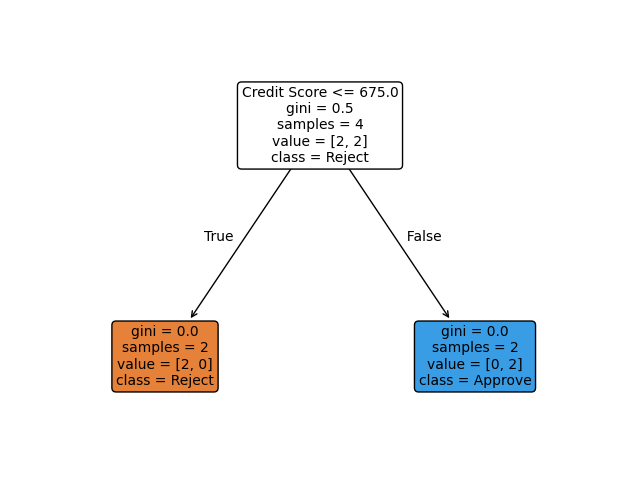

In [22]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

X_loan = [[600], [650], [700], [750]]
y_loan = [0, 0, 1, 1]

cart_classifier = DecisionTreeClassifier(criterion='gini')
cart_classifier.fit(X_loan, y_loan)

new_score = [[710]]
loan_pred = cart_classifier.predict(new_score)
print(f"CART Classification: Score 710 Approved? {'Yes' if loan_pred[0] == 1 else 'No'}")

plt.figure(figsize=(8, 6))  
tree.plot_tree(cart_classifier,           
               feature_names=['Credit Score'], 
               class_names=['Reject', 'Approve'], 
               filled=True,                                      
               rounded=True,                                     
               fontsize=10)
plt.show()

## CART: Salary Prediction (Regression)

CART Regression: Predicted Salary for 11 years: $110.0k


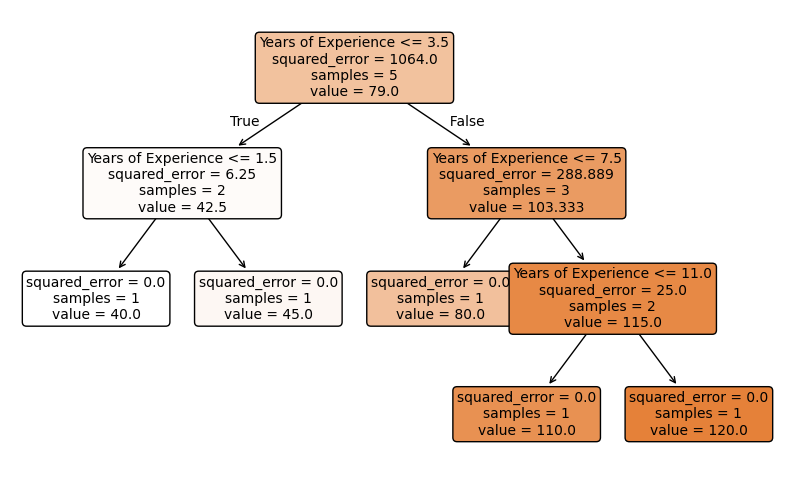

In [24]:
from sklearn.tree import DecisionTreeRegressor

# X = Years of Experience, y = Salary ($k)
X_exp = [[1], [2], [5], [10], [12]]
y_salary = [40, 45, 80, 110, 120]

# Regression Tree
cart_regressor = DecisionTreeRegressor(criterion='squared_error')
cart_regressor.fit(X_exp, y_salary)

# Inference for a person with 11 years of experience
new_exp = [[11]]
salary_pred = cart_regressor.predict(new_exp)

print(f"CART Regression: Predicted Salary for 11 years: ${salary_pred[0]}k")

plt.figure(figsize=(10, 6))
tree.plot_tree(cart_regressor,           
               feature_names=['Years of Experience'], 
               filled=True,              
               rounded=True,             
               fontsize=10)
plt.show()

### Exercise 1: Classification using Entropy
Predict if a person will Buy a Smartwatch based on their Age and Income Level.

```
'Age': ['Young', 'Young', 'Middle', 'Senior', 'Senior', 'Senior', 'Middle', 'Young']

'Income': ['High', 'Low', 'High', 'Medium', 'Low', 'Medium', 'Low', 'Medium']

'Buy': ['No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No']
```

Prediction for Middle/Medium: Yes


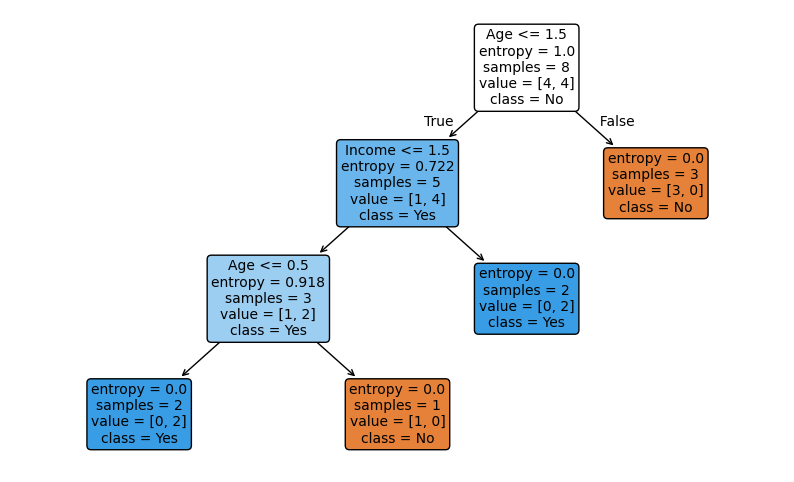

In [30]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

data_watch = {
    'Age': ['Young', 'Young', 'Middle', 'Senior', 'Senior', 'Senior', 'Middle', 'Young'],
    'Income': ['High', 'Low', 'High', 'Medium', 'Low', 'Medium', 'Low', 'Medium'],
    'Buy': ['No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No']
}

df_watch = pd.DataFrame(data_watch)

encoders = {}
features = pd.DataFrame()

for col in ['Age', 'Income']:
    le = LabelEncoder()
    features[col] = le.fit_transform(df_watch[col])
    encoders[col] = le 

le_target = LabelEncoder()
labels = le_target.fit_transform(df_watch['Buy'])

cart_classifier = DecisionTreeClassifier(criterion='entropy')
cart_classifier.fit(features, labels)

new_age = encoders['Age'].transform(['Middle'])[0]
new_income = encoders['Income'].transform(['Medium'])[0]
new_data_df = pd.DataFrame([[new_age, new_income]], columns=['Age', 'Income'])

prediction = cart_classifier.predict(new_data_df)
result = le_target.inverse_transform(prediction)
print(f"Prediction for Middle/Medium: {result[0]}")

plt.figure(figsize=(10, 6))
plot_tree(cart_classifier, 
          feature_names=['Age', 'Income'], 
          class_names=le_target.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()

## Exercise 2: CART Classification (Continuous)
Predict if a Student Passes an exam based on Hours Studied and Attendance %. This mimics the "Loan Approval" logic we discussed.

```
data_exam = {
    'Hours_Studied': [1, 2, 3, 5, 6, 8, 10, 11],
    'Attendance_Pct': [60, 40, 85, 50, 90, 80, 95, 70],
    'Pass': [0, 0, 0, 0, 1, 1, 1, 1]
}
```

Prediction for 7 hours study and 75% attendance: PASS


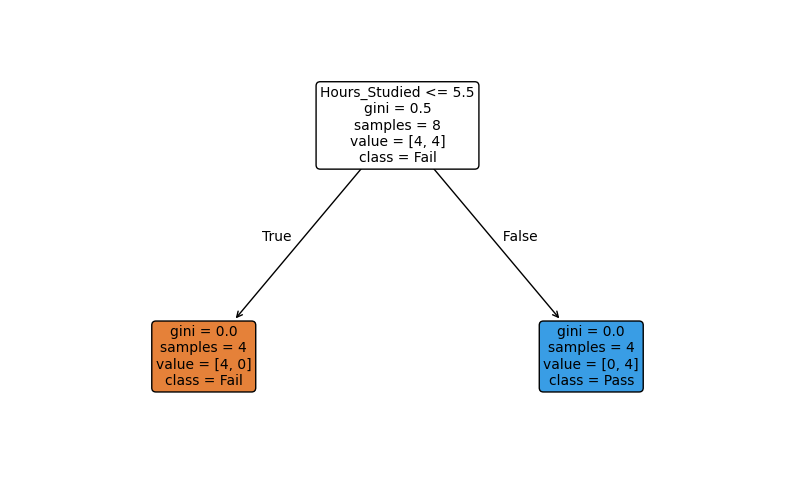

In [31]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

data_exam = {
    'Hours_Studied': [1, 2, 3, 5, 6, 8, 10, 11],
    'Attendance_Pct': [60, 40, 85, 50, 90, 80, 95, 70],
    'Pass': [0, 0, 0, 0, 1, 1, 1, 1]
}

df_exam = pd.DataFrame(data_exam)

X = df_exam[['Hours_Studied', 'Attendance_Pct']]
y = df_exam['Pass']

model = DecisionTreeClassifier(criterion='gini', random_state=42)
model.fit(X, y)

new_student = pd.DataFrame([[7, 75]], columns=X.columns)
prediction = model.predict(new_student)

result = "PASS" if prediction[0] == 1 else "FAIL"
print(f"Prediction for 7 hours study and 75% attendance: {result}")

plt.figure(figsize=(10, 6))
plot_tree(model, 
          feature_names=X.columns, 
          class_names=['Fail', 'Pass'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()